In [2]:
import os
import platform
from datetime import datetime

os_info = f"{platform.system()} {platform.release()}"
timestamp = datetime.now().strftime("%d-%m-%Y %H:%M:%S")

print(f"Current OS: {os_info}")
print(f"Log Timestamp: {timestamp}")

Current OS: Linux 6.17.0-22-generic
Log Timestamp: 28-03-2026 14:48:45


# **EXperiment 10: Data Visualization III**
1. List down the features and their types (e.g., numeric, nominal) available in the dataset.
2. Create a histogram for each feature in the dataset to illustrate the feature distributions.
3. Create a boxplot for each feature in the dataset.
4. Compare distributions and identify outliers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math

# Load dataset from local directory
dataset_path = os.path.join("datasets", "iris.csv")
df = pd.read_csv(dataset_path)

# Quick check on the grind
print("--- Dataset Information ---")
print(df.info())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB
None


### 1. Feature Listing & Type Identification
We scan the dataset to identify numeric boosters and nominal (categorical) labels.

In [2]:
print("\n--- Feature Types ---")
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"{column}: Nominal (Categorical)")
    else:
        print(f"{column}: Numeric")

# Identify numeric columns for plotting
numeric_cols = df.select_dtypes(include=[np.number]).columns
num_features = len(numeric_cols)

# Booster: Calculate dynamic grid size to avoid ValueError
n_cols = 2
n_rows = math.ceil(num_features / n_cols)


--- Feature Types ---
Id: Numeric
SepalLengthCm: Numeric
SepalWidthCm: Numeric
PetalLengthCm: Numeric
PetalWidthCm: Numeric
Species: Nominal (Categorical)


### 2. Histograms: Feature Distributions
Using dynamic subplots to visualize the density of each subtask.

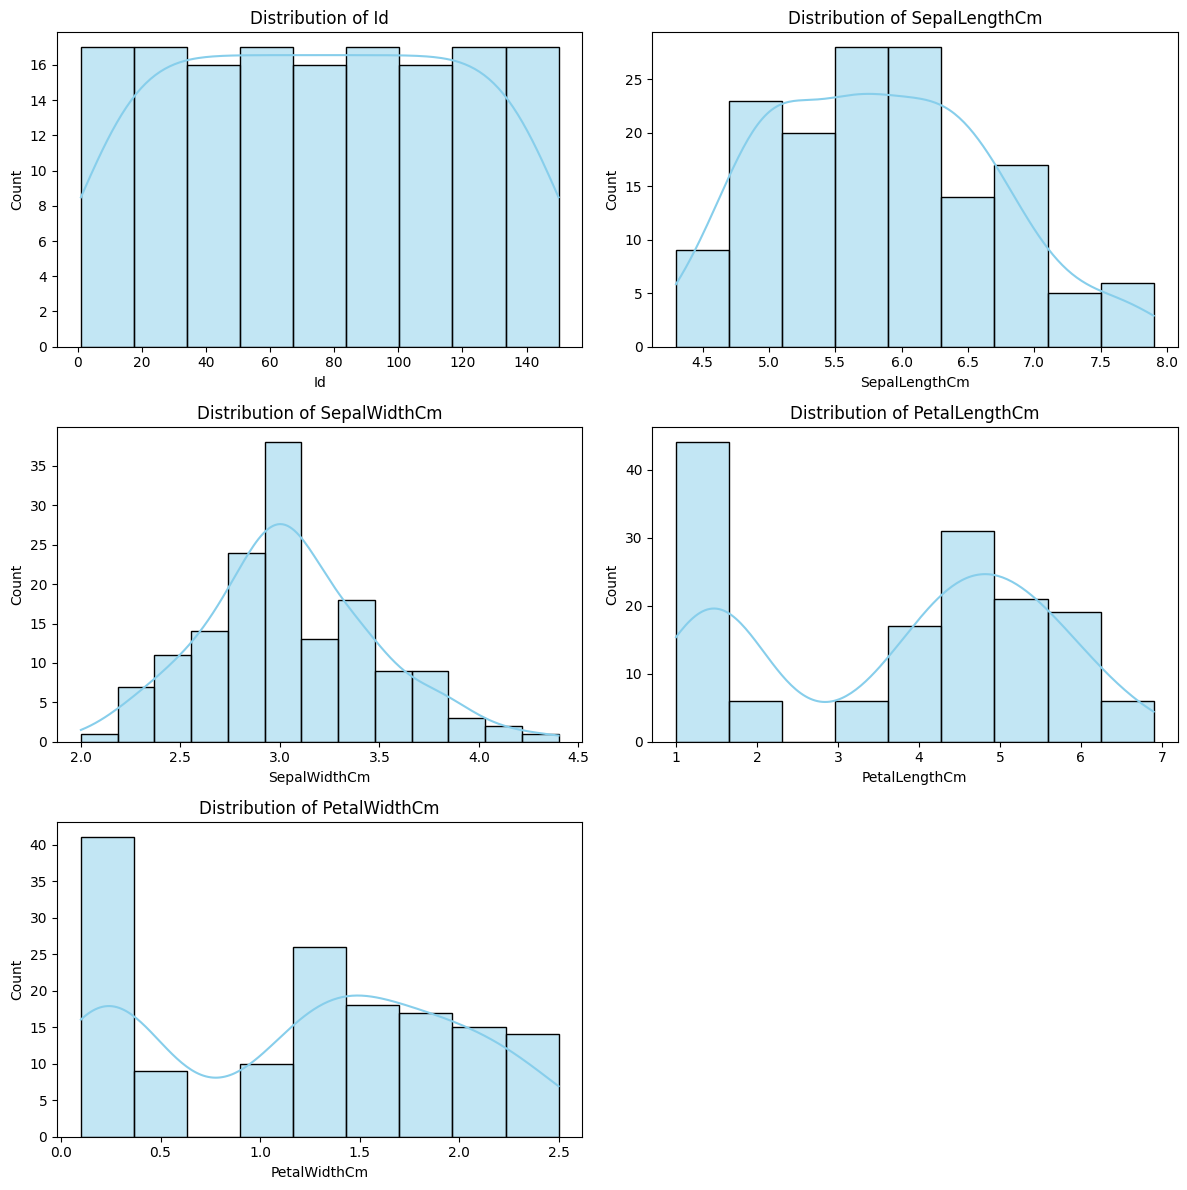

In [3]:
plt.figure(figsize=(12, 4 * n_rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

### 3. Boxplots: Outlier Detection
Identifying "noisy" data points that deviate from the interquartile range.

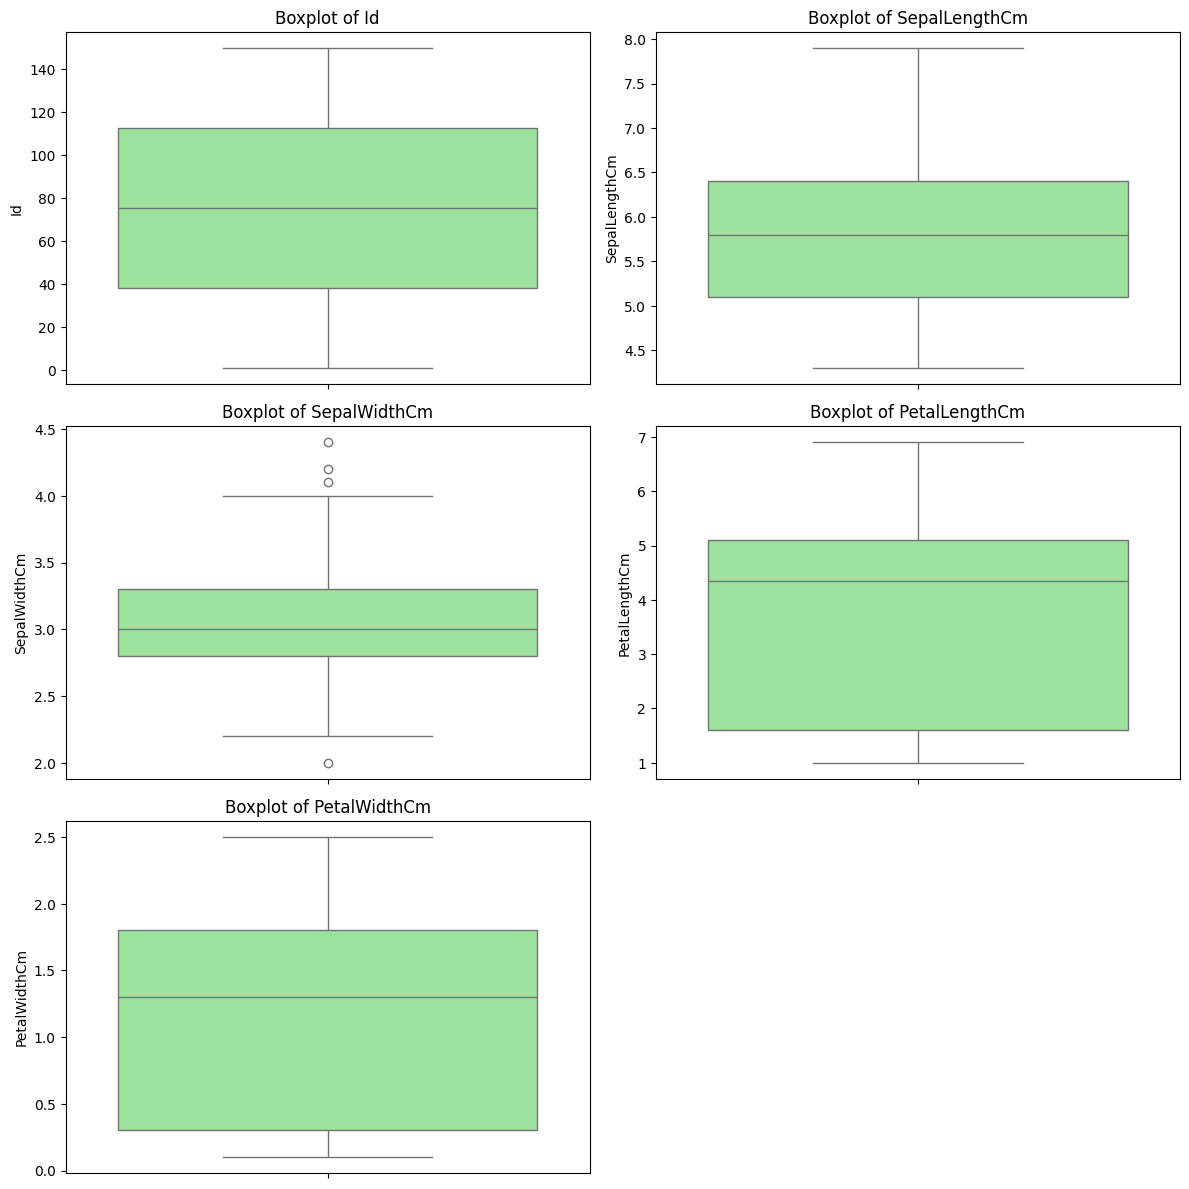

In [4]:
plt.figure(figsize=(12, 4 * n_rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(y=df[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

### 4. Inferences: Distribution Comparison & Outliers
Evaluating skewness and summary stats to finalize the experiment logic.

In [5]:
# Calculating skewness to compare distributions
print("--- Skewness of Features ---")
print(df[numeric_cols].skew())

# Descriptive stats for outlier context
print("\n--- Summary Statistics ---")
print(df.describe())

--- Skewness of Features ---
Id               0.000000
SepalLengthCm    0.314911
SepalWidthCm     0.334053
PetalLengthCm   -0.274464
PetalWidthCm    -0.104997
dtype: float64

--- Summary Statistics ---
               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000
